# Generador de trayectorias joint

In [ ]:
# Para correr en Colab
%pip install roboticstoolbox-python
%pip install numpy==1.26.4 --force-reinstall

# Nota importante: da error porque un montón de bibliotecas de Colab dependen de numpy 2, 
# pero como no se utilizan no importa. 
#
# Cuando termina de ejecutarse la celda, pide reiniciar el kernel (aparece un botón bien evidente)
# Luego de reiniciar correr las celdas siguientes

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

## Interpolador trapezoidal

Tiene 2 zonas:
- Cambio de velocidad (interpolación cuadrática)
- Velocidad constante

In [73]:
def interp_trapezoidal(theta_points, Td, vmax=None, tacc=200e-3, tm=1e-3):
    """
    Interpolación tipo trapezoidal multi-segmento

    Parameters
    ----------
    theta_points : np.ndarray (n_joints, n_points)
        Puntos de paso (cada columna es una configuración)
    Td : list or np.ndarray
        Tiempo deseado por segmento
    vmax : float or np.ndarray
        Velocidad máxima por eje
    tacc : float
        Tiempo de aceleración
    tm : float
        Tiempo de muestreo

    Returns
    -------
    t : np.ndarray
    q : np.ndarray
    qp : np.ndarray
    qpp : np.ndarray
    """

    theta_points = np.array(theta_points)
    Td = np.array(Td)

    n_points, n_joints  = theta_points.shape

    # Asegurar forma de vmax
    if vmax is None:
        vmax = 1E9
    vmax = np.array(vmax)
    if vmax.size == 1:
        vmax = vmax * np.ones(n_joints)

    q_list = []
    qp_list = []
    qpp_list = []

    A = theta_points[0, :]

    for i in range(n_points - 1):
        B = theta_points[i,:]
        C = theta_points[i + 1,:]

        DA = A - B
        DC = C - B

        T1 = max([
            np.max(np.abs(DC) / vmax),
            Td[i],
            2 * tacc
        ])

        # -------- Evolución temporal. Se deduce que este algoritmo no es RT
        for tseg in np.arange(-tacc + tm, T1 - tacc + tm, tm):

            if tseg <= tacc:
                # ----- Zona 1 (aceleración)
                theta2p = (DC / T1 + DA / tacc) / (2 * tacc)

                thetap = (DC / T1) * (tseg + tacc) / (2 * tacc) + \
                        (DA / tacc) * (tseg - tacc) / (2 * tacc)

                theta = (DC / T1) * (tseg + tacc) ** 2 / (4 * tacc) + \
                        (DA / tacc) * (tseg - tacc) ** 2 / (4 * tacc) + B
            else:
                # ----- Zona 2 (velocidad constante)
                theta2p = np.zeros(n_joints)
                thetap = DC / T1
                theta = (DC / T1) * tseg + B

            q_list.append(theta)
            qp_list.append(thetap)
            qpp_list.append(theta2p)

        A = theta   # continuidad

    # Convertir a arrays
    q = np.array(q_list)
    qp = np.array(qp_list)
    qpp = np.array(qpp_list)

    t = np.arange(1, len(q) + 1) * tm    

    return t, q, qp, qpp

In [101]:
def plot_joint(t, q, qp, qpp, title="Interpolación Joint"):
    fig, axs = plt.subplots(3, 1, sharex=True)

    axs[0].plot(t, q, linewidth=2)
    axs[0].set_ylabel("$q$")
    axs[0].set_title(title)
    axs[0].grid(True)

    axs[1].plot(t[0:len(qp)], qp, linewidth=2)
    axs[1].set_ylabel("$\dot{q}$")
    axs[1].grid(True)

    axs[2].plot(t[0:len(qpp)], qpp, linewidth=2)
    axs[2].set_ylabel("$\ddot{q}$")
    axs[2].set_xlabel("tiempo [s]")
    axs[2].grid(True)

    plt.xlim([0, t[-1]])
    plt.tight_layout()
    plt.show()

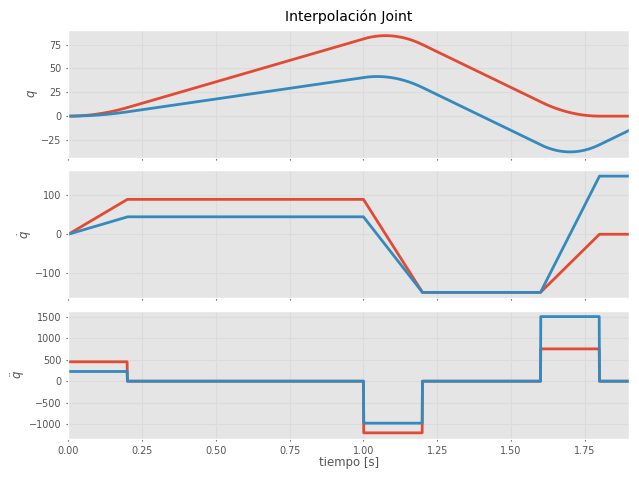

In [75]:
# Datos de ejemplo
tm = 1e-3
tacc = 100e-3
vmax = 150

Td = [1, 0, 0]  # ojo: len = n_segments
theta_n = np.array([
    [0, 0],
    [90, 45],
    [0, -45],
    [0, 0]
])

t, q, qp, qpp = interp_trapezoidal(theta_n, Td, vmax, tacc, tm)

plot_joint(t, q, qp, qpp)



## Interpolador S-profile

In [76]:
def interp_Sprofile(theta_points, Td, vmax=None, tacc=200E-3, orden=4, metodo=1, tm=1e-3):
    """
    Interpolación tipo S-profile multi-segmento

    metodo = 0 → Paul (cuadrático)
    metodo = 1 → Polinómico de orden arbitrario (par)
    """

    theta_points = np.array(theta_points)
    Td = np.array(Td)

    n_points, n_joints = theta_points.shape

    if vmax is None:
        vmax = 1E9
    vmax = np.array(vmax)
    if vmax.size == 1:
        vmax = vmax * np.ones(n_joints)

    if metodo > 0 and (orden % 2 != 0):
        raise ValueError("El orden de interpolación debe ser par")

    q_list, qp_list, qpp_list = [], [], []

    A = theta_points[0,:]

    for i in range(n_points - 1):
        B = theta_points[i,:]
        C = theta_points[i + 1,:]

        DA = A - B
        DC = C - B

        T1 = max([
            np.max(np.abs(DC) / vmax),
            Td[i],
            2 * tacc
        ])

        # -------- Polinomio (si corresponde)
        if metodo > 0:
            VA = (B - A) / tacc
            VD = (C - B) / T1

            n = np.arange(orden, -1, -1)

            M = [(-tacc) ** n]
            coef = np.ones_like(n, dtype=float)
            n_min = n.copy()

            for _ in range(orden // 2):
                coef = coef * n_min
                n_min = np.where(n_min - 1 > 0, n_min - 1, 0)
                M.append(coef * (-tacc) ** n_min)
                M.append(coef * (tacc) ** n_min)

            M = np.vstack(M)

            rhs = np.vstack([
                A,
                VA,
                VD,
                np.zeros((M.shape[0] - 3, n_joints))
            ])

            p_inter = np.linalg.inv(M) @ rhs  # (orden+1, n_joints)

        # -------- Loop unificado
        for tseg in np.arange(-tacc + tm, T1 - tacc + tm, tm):

            if tseg <= tacc:
                # ----- Zona 1
                if metodo == 0:
                    theta2p = (DC / T1 + DA / tacc) / (2 * tacc)

                    thetap = (DC / T1) * (tseg + tacc) / (2 * tacc) + \
                             (DA / tacc) * (tseg - tacc) / (2 * tacc)

                    theta = (DC / T1) * (tseg + tacc) ** 2 / (4 * tacc) + \
                            (DA / tacc) * (tseg - tacc) ** 2 / (4 * tacc) + B
                else:
                    theta = p_inter.T @ (tseg ** n)

                    exp1 = np.where((n - 1) > 0, n - 1, 0)
                    thetap = p_inter.T @ (n * (tseg ** exp1))

                    exp2 = np.where((n - 2) > 0, n - 2, 0)
                    theta2p = p_inter.T @ (n * exp1 * (tseg ** exp2))

            else:
                # ----- Zona 2
                theta2p = np.zeros(n_joints)
                thetap = DC / T1
                theta = (DC / T1) * tseg + B

            q_list.append(theta)
            qp_list.append(thetap)
            qpp_list.append(theta2p)


        A = theta  # continuidad

    q = np.array(q_list)
    qp = np.array(qp_list)
    qpp = np.array(qpp_list)
    t = np.arange(1, len(q) + 1) * tm    

    return t, q, qp, qpp



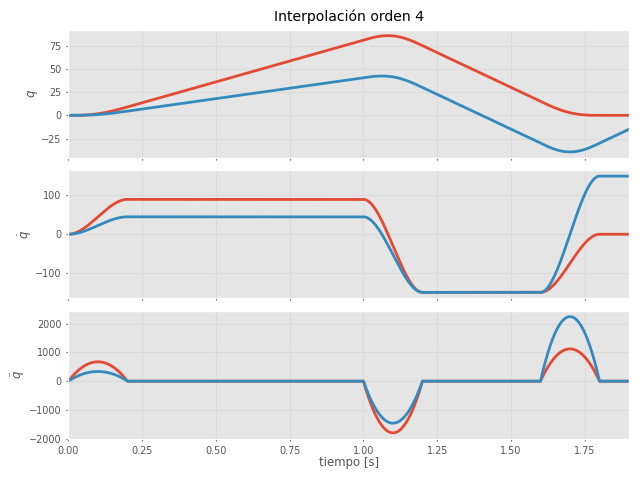

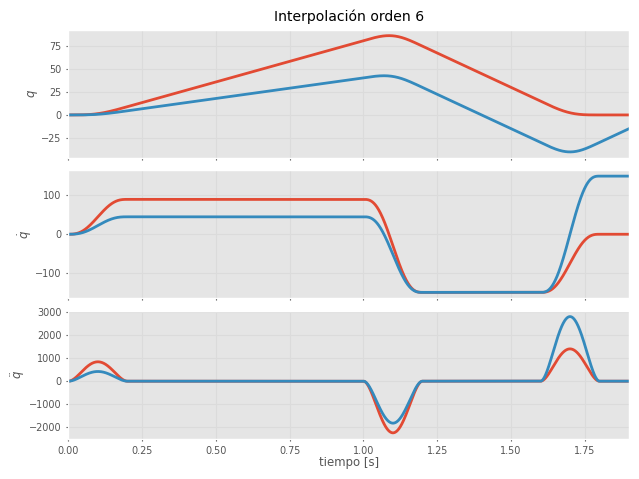

In [77]:
t4, q4, qp4, qpp4 = interp_Sprofile(theta_n, Td, vmax=vmax, tacc=tacc, tm=tm)
plot_joint(t4, q4, qp4, qpp4, title="Interpolación orden 4")

t6, q6, qp6, qpp6 = interp_Sprofile(theta_n, Td, vmax=vmax, tacc=tacc, tm=tm, orden=6)
plot_joint(t6, q6, qp6, qpp6, title="Interpolación orden 6")


## Comparación de interpoladores

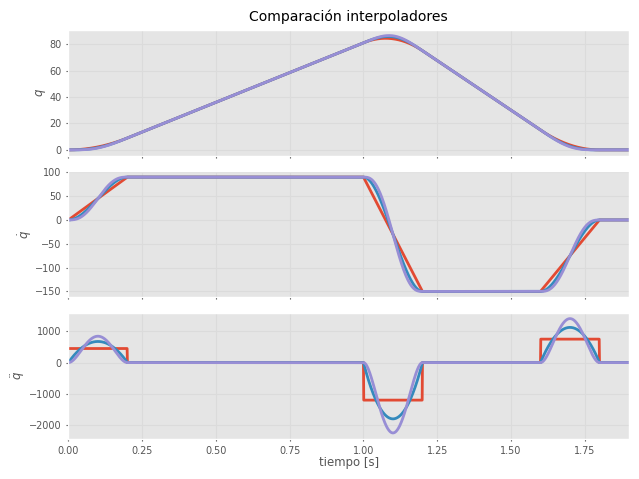

In [78]:
q_stack = np.vstack((q[:,0],q4[:,0],q6[:,0])).T
qp_stack = np.vstack((qp[:,0],qp4[:,0],qp6[:,0])).T
qpp_stack = np.vstack((qpp[:,0],qpp4[:,0],qpp6[:,0])).T

plot_joint(t, q_stack, qp_stack, qpp_stack, title="Comparación interpoladores")


## Interpolador de roboticstoolbox

Se revisan 2 casos:
- Un único segmento con interpolación polinomial (jtraj)
- Un único segmento con interpolación trapezoidal o polinomial (mtraj)
- Múltiples segmentos (mstraj), deteniéndose en cada punto


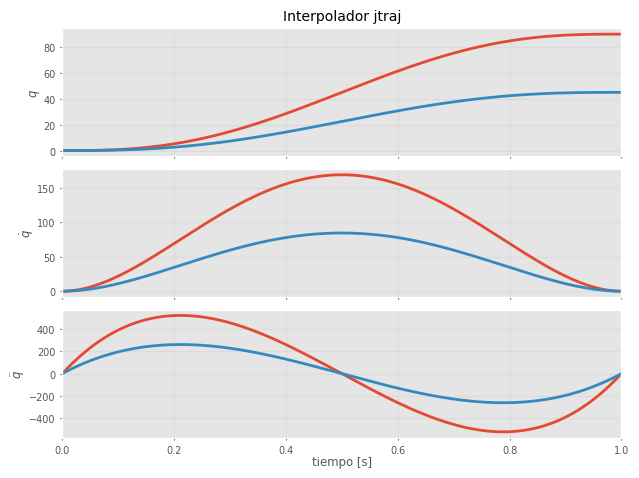

In [108]:

# Configuración inicial y final
q0 = np.array([0, 0])
qf = np.array([90, 45])

# Tiempo
t = np.linspace(0, 1, 200)

# Interpolación trapezoidal
traj = rtb.jtraj(q0, qf, t)

plot_joint(t,traj.q,traj.qd,traj.qdd,title="Interpolador jtraj")


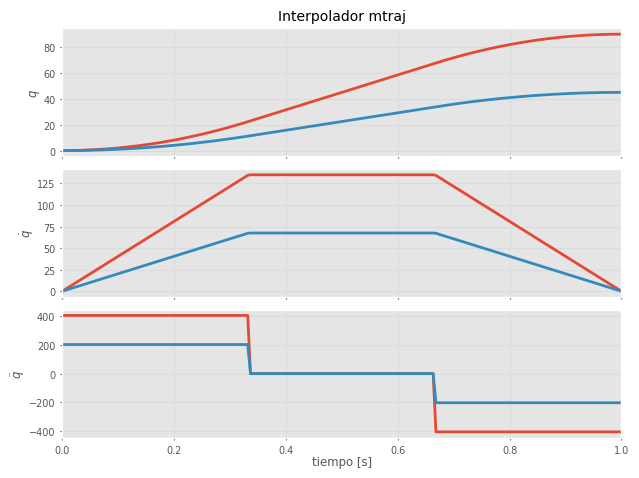

In [109]:
# Interpolación usando perfil trapezoidal
traj = rtb.mtraj(rtb.trapezoidal, q0, qf, t)
plot_joint(traj.t,traj.q,traj.qd,traj.qdd,title="Interpolador mtraj")


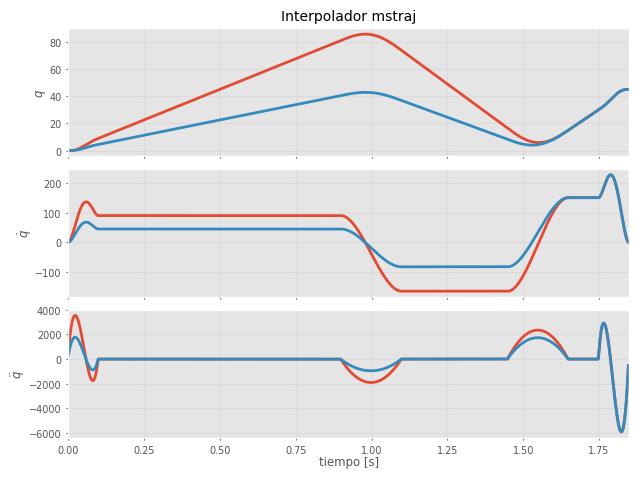

In [102]:
# Waypoints (cada fila es un punto)
via = np.array([
    [0, 0],
    [90, 45],
    [0, 0],
    [45, 45]
])

# Parámetros
qdmax = [1500, 1500]

# Interpolación multi-segmento
traj = rtb.mstraj(
    via,
    dt=1E-3,
    tacc=200E-3,
    tsegment=np.array([1,0.55,0.3]),
    #qdmax=qdmax
)

qd = np.diff(traj.q,axis=0)/tm
qdd = np.diff(qd,axis=0)/tm
plot_joint(traj.t,traj.q,qd,qdd,title="Interpolador mstraj")


| Método           | Orden    | Multi-seg | Continuidad | Realismo físico |
| ---------------- | -------- | --------- | ----------- | --------------- |
| `jtraj`          | 5        | ❌         | q, qp, qpp  | 🟡 medio        |
| `mtraj`           | 2        | ❌         | q, qp       | 🟢 bueno        |
| `mstraj`         | mix      | ✔         | pobre       | 🔴 flojo        |
| **S-profile hecho en casa** | variable | ✔         | hasta jerk  | 🟢🟢 excelente  |


## Versión en tiempo real para armar en controlador

In [ ]:
def interp_joint_rt_step(state, Ts, vmax, tacc):
    """
    Un paso de interpolación en tiempo real.

    state: dict con el estado interno (se modifica in-place)
    Ts: tiempo de muestreo
    vmax: escalar o vector
    tacc: tiempo de aceleración

    Returns
    -------
    q, qp, qpp, done
    """

    n_joints = state['q'].size

    vmax = np.array(vmax)
    if vmax.size == 1:
        vmax = vmax * np.ones(n_joints)

    tseg = state['tseg']
    Tj = state['Tj']
    j = state['j']
    moves = state['moves']

    # -------- Cambio de segmento
    if tseg >= (Tj - tacc) + (Ts * 0.5):

        if j >= len(moves):
            return state['q'], state['qp'], state['qpp'], True

        move = moves[j]
        state['j'] += 1

        qA = state['q'].copy()
        qB = state['qC'].copy()
        qC = np.array(move['q'])

        DA = qA - qB
        DC = qC - qB

        Tj = max([
            np.max(np.abs(DC) / vmax),
            move['td'],
            2 * tacc
        ])
        Tj = np.ceil(Tj / Ts) * Ts

        # Guardar en estado
        state['qA'] = qA
        state['qB'] = qB
        state['qC'] = qC
        state['DA'] = DA
        state['DC'] = DC
        state['Tj'] = Tj

        state['tseg'] = -tacc + Ts
        tseg = state['tseg']

    else:
        # usar valores actuales
        qB = state['qB']
        DA = state['DA']
        DC = state['DC']

    # -------- Evaluación del perfil
    if tseg < tacc:
        qpp = (DC / Tj + DA / tacc) / (2 * tacc)

        qp = (DC / Tj) * (tseg + tacc) / (2 * tacc) + \
             (DA / tacc) * (tseg - tacc) / (2 * tacc)

        q = (DC / Tj) * (tseg + tacc) ** 2 / (4 * tacc) + \
            (DA / tacc) * (tseg - tacc) ** 2 / (4 * tacc) + qB

    else:
        qpp = np.zeros(n_joints)
        qp = DC / Tj
        q = (DC / Tj) * tseg + qB

    # -------- Actualizar estado
    state['q'] = q
    state['qp'] = qp
    state['qpp'] = qpp

    state['tseg'] += Ts
    state['tr'] += Ts

    return q, qp, qpp, False

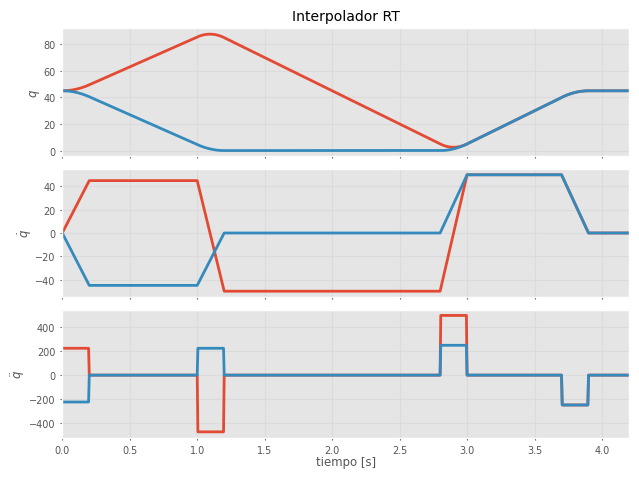

In [112]:
def init_rt_state(moves, q_ini):
    q_ini = np.array(q_ini)

    return {
        'moves': moves,
        'j': 0,

        'q': q_ini.copy(),
        'qp': np.zeros_like(q_ini),
        'qpp': np.zeros_like(q_ini),

        'qA': q_ini.copy(),
        'qB': q_ini.copy(),
        'qC': q_ini.copy(),
        'DA': np.zeros_like(q_ini),
        'DC': np.zeros_like(q_ini),

        'tseg': 0.0,
        'tr': 0.0,
        'Tj': 0.0,
    }

Ts = 5e-3
tacc = 0.1
vmax = 50

moves = [
    {'td': 1,   'q': [90, 0]},
    {'td': 1,   'q': [0, 0]},
    {'td': 0.5, 'q': [45, 45]},
    {'td': 0.5, 'q': [45, 45]},
]

state = init_rt_state(moves, q_ini=[45, 45])

t_log, q_log, qp_log, qpp_log = [], [], [], []

while True:
    q, qp, qpp, done = interp_joint_rt_step(state, Ts, vmax, tacc)

    t_log.append(state['tr'])
    q_log.append(q.copy())
    qp_log.append(qp.copy())
    qpp_log.append(qpp.copy())

    if done:
        break

# convertir
t = np.array(t_log)
q = np.array(q_log)
qp = np.array(qp_log)
qpp = np.array(qpp_log)

plot_joint(t, q, qp, qpp, title="Interpolador RT")